In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ======================================================
# 1. Define your MLP
# ======================================================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.fc4(x)

# ======================================================
# 2. MNIST loaders
# ======================================================
transform = transforms.ToTensor()
train_ds = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds,  batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,   batch_size=512, shuffle=False)

loss_fn = nn.CrossEntropyLoss()

# ======================================================
# 3. Train a model
# ======================================================
def train_model(epochs=2):
    model = MLP()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        for x, y in train_loader:
            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()
        print(f"Epoch {epoch+1} done.")
    return model

print("Training model A...")
modelA = train_model()

print("Training model B...")
modelB = train_model()

# ======================================================
# 4. Flatten helpers
# ======================================================
def flatten_state(state_dict):
    flat = []
    meta = []
    for k, v in state_dict.items():
        arr = v.detach().cpu().numpy().ravel()
        flat.append(arr)
        meta.append((k, v.shape, arr.size))
    return np.concatenate(flat), meta

def unflatten_state(vec, meta):
    d = {}
    offset = 0
    for k, shape, size in meta:
        part = vec[offset:offset+size]
        offset += size
        d[k] = torch.from_numpy(part.reshape(shape)).float()
    return d

stateA = modelA.state_dict()
stateB = modelB.state_dict()

flatA, metaA = flatten_state(stateA)
flatB, metaB = flatten_state(stateB)

# ======================================================
# 5. Build a 2D plane using A→B and a random orthogonal direction
# ======================================================
u = flatB - flatA
u_norm = np.linalg.norm(u) + 1e-12
u_hat = u / u_norm

rng = np.random.RandomState(0)
v = rng.randn(*flatA.shape)
v = v - (np.dot(v, u_hat) * u_hat)   # make v orthogonal to u
v_norm = np.linalg.norm(v) + 1e-12
v_hat = v / v_norm

# ======================================================
# 6. Evaluate loss at each grid point (FAST VERSION)
# ======================================================
def eval_vector(w_vec):
    state = unflatten_state(w_vec, metaA)
    m = MLP()
    m.load_state_dict(state)
    m.eval()
    total, correct, loss_total = 0, 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            out = m(x)
            loss_total += loss_fn(out, y).item()
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return loss_total/total, correct/total

G = 11        # FAST GRID (11×11 = 121 evals)
margin = 0.3
alphas = np.linspace(-margin, 1+margin, G)
betas  = np.linspace(-margin, 1+margin, G)

loss_grid = np.zeros((G,G))
acc_grid  = np.zeros((G,G))
xy_grid   = np.zeros((G,G,2))

counter = 0
print("Evaluating plane...")

for i,a in enumerate(alphas):
    for j,b in enumerate(betas):
        counter += 1
        w = flatA + a*u_norm*u_hat + b*v_norm*v_hat
        loss, acc = eval_vector(w)
        loss_grid[i,j] = loss
        acc_grid[i,j]  = acc
        xy_grid[i,j]   = [a*u_norm, b*v_norm]
        print(f"[{counter}/{G*G}] loss={loss:.3f} acc={acc:.3f}")

OUTFILE = "planeAB_2point.npz"
np.savez(OUTFILE,
         grid=xy_grid,
         loss=loss_grid,
         acc=acc_grid,
         alphas=alphas,
         betas=betas)

print(f"Saved: {OUTFILE}")



Training model A...
Epoch 1 done.
Epoch 2 done.
Training model B...
Epoch 1 done.
Epoch 2 done.
Evaluating plane...
[1/121] loss=1.044 acc=0.082
[2/121] loss=0.059 acc=0.218
[3/121] loss=0.001 acc=0.963
[4/121] loss=0.087 acc=0.294
[5/121] loss=1.273 acc=0.145
[6/121] loss=6.090 acc=0.126
[7/121] loss=18.778 acc=0.117
[8/121] loss=45.343 acc=0.113
[9/121] loss=93.530 acc=0.110
[10/121] loss=172.859 acc=0.106
[11/121] loss=294.545 acc=0.104
[12/121] loss=0.985 acc=0.075
[13/121] loss=0.056 acc=0.155
[14/121] loss=0.000 acc=0.964
[15/121] loss=0.089 acc=0.233
[16/121] loss=1.281 acc=0.141
[17/121] loss=6.136 acc=0.123
[18/121] loss=18.958 acc=0.116
[19/121] loss=45.795 acc=0.111
[20/121] loss=94.467 acc=0.107
[21/121] loss=174.509 acc=0.104
[22/121] loss=297.226 acc=0.103
[23/121] loss=0.935 acc=0.072
[24/121] loss=0.053 acc=0.120
[25/121] loss=0.000 acc=0.962
[26/121] loss=0.094 acc=0.195
[27/121] loss=1.294 acc=0.136
[28/121] loss=6.208 acc=0.120
[29/121] loss=19.191 acc=0.113
[30/121]

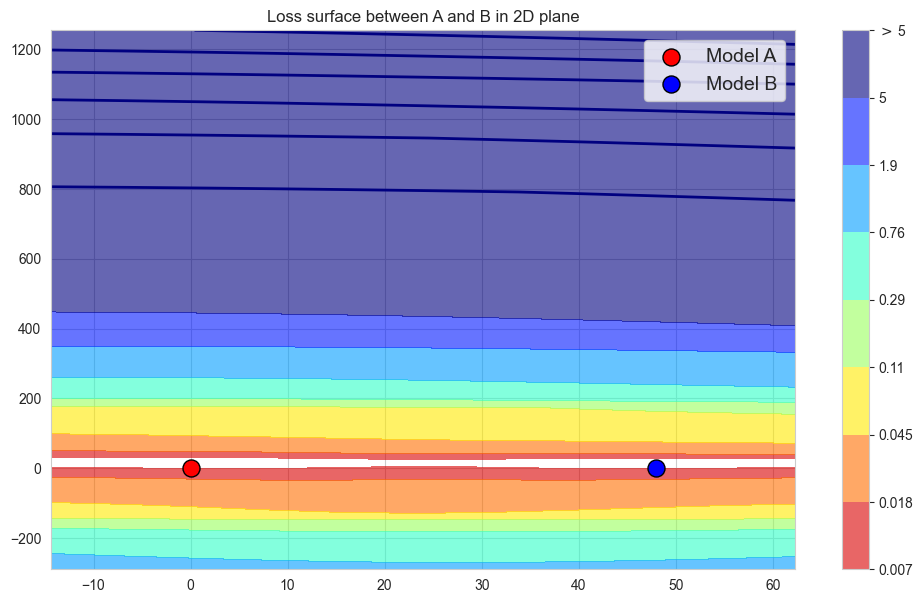

In [13]:
# plane_plot_jupyter.py — second cell to plot pretty contours

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

file = np.load("planeAB_2point.npz")
grid = file['grid']
loss = file['loss']

sns.set_style('whitegrid')

# custom log-style normalization used in the paper
class LogNormalize(colors.Normalize):
    def __init__(self, vmin=None, vmax=None, clip=None, log_alpha=None):
        self.log_alpha = log_alpha
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        log_v = np.ma.log(value - self.vmin + 1e-12)
        log_v = np.ma.maximum(log_v, self.log_alpha)
        return 0.9 * (log_v - self.log_alpha) / (np.log(self.vmax - self.vmin + 1e-12) - self.log_alpha)

def plot_plane(grid, values, vmax=None, log_alpha=-5, N=7, cmap='jet_r'):
    cmap = plt.get_cmap(cmap)
    clipped = np.minimum(values, vmax) if vmax else values.copy()
    log_gamma = (np.log(clipped.max() - clipped.min() + 1e-12) - log_alpha) / N
    levels = clipped.min() + np.exp(log_alpha + log_gamma*np.arange(N+1))
    levels = np.concatenate((levels, [1e10]))
    norm = LogNormalize(clipped.min()-1e-8, clipped.max()+1e-8, log_alpha=log_alpha)
    contour = plt.contour(grid[:,:,0], grid[:,:,1], values, cmap=cmap, norm=norm, linewidths=2)
    contourf = plt.contourf(grid[:,:,0], grid[:,:,1], values, cmap=cmap, norm=norm, levels=levels, alpha=0.6)
    cbar = plt.colorbar(format="%.2g")
    labels = list(cbar.ax.get_yticklabels())
    labels[-1].set_text(r'$>\,$' + labels[-2].get_text())
    cbar.ax.set_yticklabels(labels)
    return contour, contourf, cbar


dx = np.linalg.norm(flatB - flatA)



plt.figure(figsize=(12,7))
plot_plane(grid, loss, vmax=5.0)
# Model A: origin (0, 0)
plt.scatter(0, 0, c='red', s=150, edgecolors='black', label='Model A')

# Model B: (dx, 0)
plt.scatter(dx, 0, c='blue', s=150, edgecolors='black', label='Model B')

plt.legend(fontsize=14)
plt.title("Loss surface between A and B in 2D plane")
plt.savefig("planeAB_loss.pdf", format="pdf")
plt.show()
